# TinyML Predictive Maintenance: Data Exploration

This notebook explores the synthetic sensor data used for predictive maintenance anomaly detection.

In [1]:
import sys
import os
sys.path.append(os.path.join('..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from tinyml_predictive_maintenance.data import generate_sensor_stream
from tinyml_predictive_maintenance.features import window_features

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

## Generate Synthetic Sensor Data

Let's generate synthetic data that simulates industrial sensors monitoring vibration, temperature, and current.

In [2]:
# Generate sensor data with anomalies starting at sample 180
df = generate_sensor_stream(samples=240, anomaly_start=180, seed=42)
print(f"Generated {len(df)} data points")
print(f"Data shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

df.head()

Generated 240 data points
Data shape: (240, 5)
Columns: ['timestamp', 'vibration', 'temperature', 'current', 'label']


,timestamp,vibration,temperature,current,label
0,0,2.599886,40.440017,2.028001,0.0
1,1,2.593467,41.578354,2.060071,0.0
2,2,2.694654,40.539102,2.040700,0.0
3,3,2.550982,40.749821,2.045938,0.0
4,4,2.565419,40.718140,2.057645,0.0


## Visualize Raw Sensor Data

Let's plot the time series data to see the normal operation and anomaly periods.

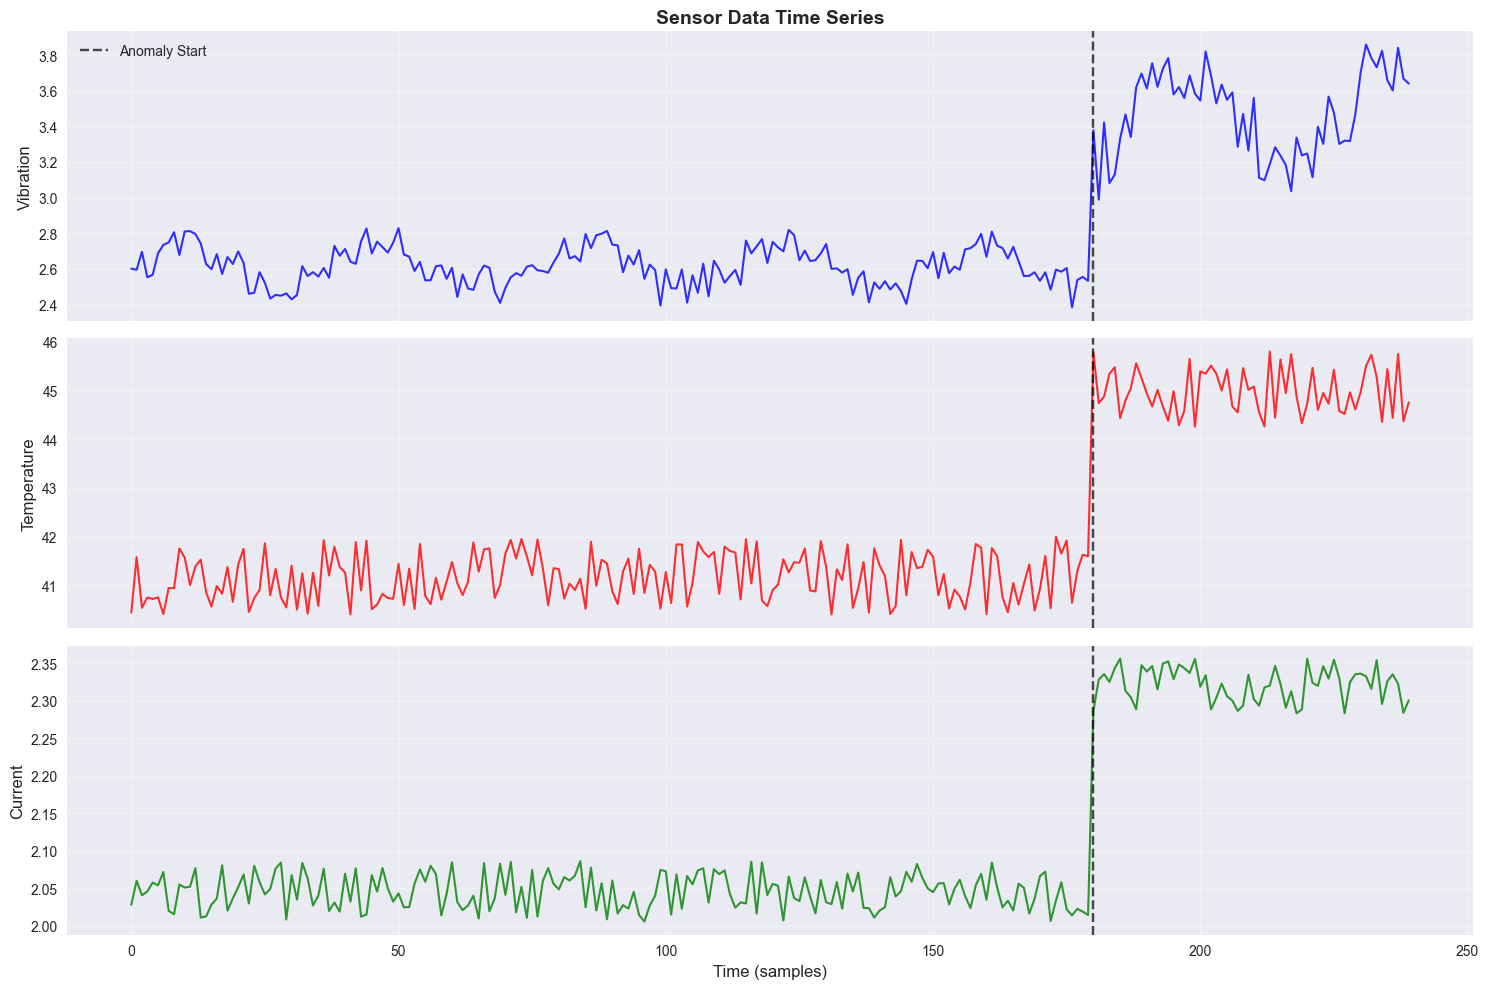

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Plot each sensor
sensors = ['vibration', 'temperature', 'current']
colors = ['blue', 'red', 'green']

for i, (sensor, color) in enumerate(zip(sensors, colors)):
    axes[i].plot(df.index, df[sensor], color=color, linewidth=1.5, alpha=0.8)
    axes[i].axvline(x=180, color='black', linestyle='--', alpha=0.7, label='Anomaly Start')
    axes[i].set_ylabel(f'{sensor.capitalize()}', fontsize=12)
    axes[i].grid(True, alpha=0.3)
    
axes[0].set_title('Sensor Data Time Series', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Time (samples)', fontsize=12)
axes[0].legend()

plt.tight_layout()
plt.show()

## Statistical Analysis

Let's examine the statistical properties of normal vs anomalous data.

In [4]:
# Split data into normal and anomalous periods
normal_data = df[df.index < 180]
anomaly_data = df[df.index >= 180]

print("Normal period statistics:")
print(normal_data[sensors].describe())
print("\nAnomalous period statistics:")
print(anomaly_data[sensors].describe())

Normal period statistics:
        vibration  temperature     current
count  180.000000   180.000000  180.000000
mean     2.615462    41.167121    2.045714
std      0.104634     0.480054    0.022908
min      2.381643    40.400650    2.005707
25%      2.550362    40.747864    2.024798
50%      2.604661    41.173639    2.045424
75%      2.690984    41.591393    2.065852
max      2.827495    41.999853    2.086277

Anomalous period statistics:
       vibration  temperature    current
count  60.000000    60.000000  60.000000
mean    3.474498    44.987667   2.321859
std     0.231537     0.462406   0.022278
min     2.987785    44.256242   2.283209
25%     3.297638    44.595673   2.303407
50%     3.537664    44.954580   2.324164
75%     3.645769    45.426481   2.337427
max     3.861092    45.798872   2.356014


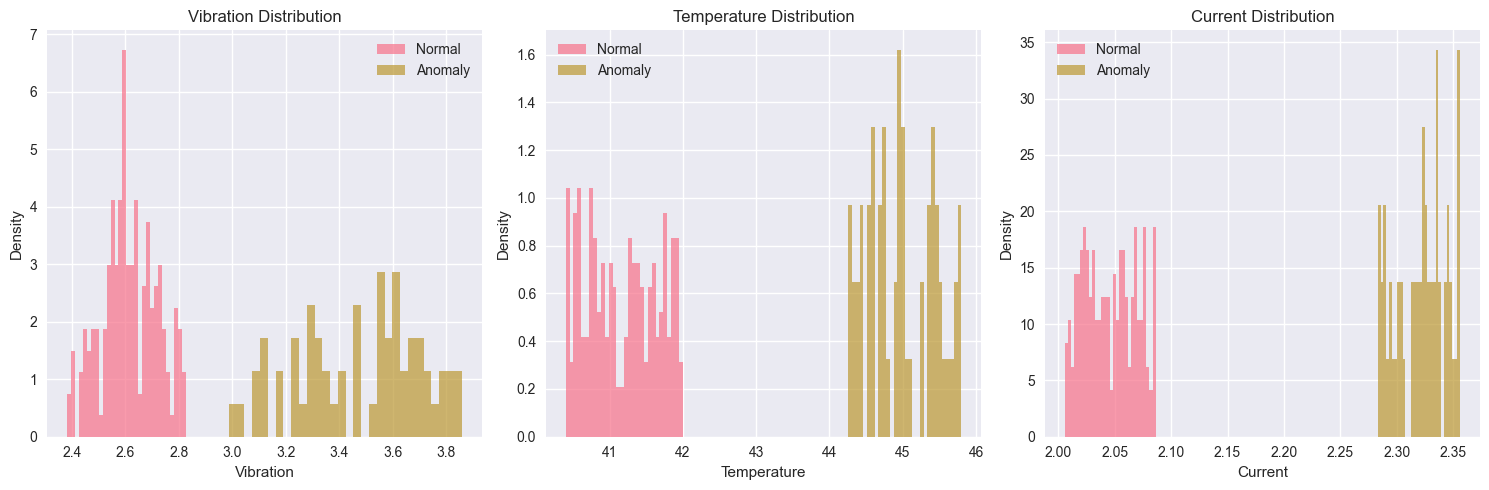

In [5]:
# Visualize distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, sensor in enumerate(sensors):
    axes[i].hist(normal_data[sensor], alpha=0.7, label='Normal', bins=30, density=True)
    axes[i].hist(anomaly_data[sensor], alpha=0.7, label='Anomaly', bins=30, density=True)
    axes[i].set_xlabel(sensor.capitalize())
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].set_title(f'{sensor.capitalize()} Distribution')

plt.tight_layout()
plt.show()

## Feature Extraction

Extract statistical features from sliding windows to prepare for anomaly detection.

In [6]:
# Extract features with sliding windows
features_df = window_features(df, window_size=24, stride=12)
print(f"Extracted {len(features_df)} feature windows")
print(f"Feature columns: {len([col for col in features_df.columns if not col.startswith('window') and col != 'label'])}")

features_df.head()

Extracted 19 feature windows
Feature columns: 21


,window_start,window_end,vibration_mean,vibration_std,vibration_max,vibration_min,vibration_rms,vibration_skew,vibration_kurtosis,temperature_mean,...,temperature_skew,temperature_kurtosis,current_mean,current_std,current_max,current_min,current_rms,current_skew,current_kurtosis,label
0,0,23,2.659272,0.100212,2.810794,2.458224,2.661081,-0.223134,-0.580581,40.997947,...,0.401573,-1.172147,2.045187,0.021623,2.080629,2.011078,2.045296,0.048180,-1.083002,0.0
1,12,35,2.567765,0.104503,2.794478,2.427055,2.569802,0.318032,-0.782657,41.006301,...,0.346844,-1.082900,2.048675,0.024765,2.084279,2.008370,2.048819,-0.018129,-1.278716,0.0
2,24,47,2.597597,0.116892,2.825457,2.427055,2.600116,0.098372,-1.042247,41.091388,...,0.313192,-1.198703,2.049057,0.024851,2.084279,2.008370,2.049202,-0.116964,-1.374290,0.0
3,36,59,2.664266,0.084721,2.827495,2.533842,2.665557,0.165596,-0.692323,41.088373,...,0.444361,-1.147449,2.046399,0.023492,2.080185,2.012171,2.046528,0.025322,-1.463207,0.0
4,48,71,2.581975,0.098026,2.827495,2.406991,2.583757,0.465853,0.148169,41.162965,...,0.296793,-1.273382,2.047306,0.024748,2.085143,2.009726,2.047449,0.290996,-1.244435,0.0


## Feature Correlation Analysis

Examine correlations between extracted features.

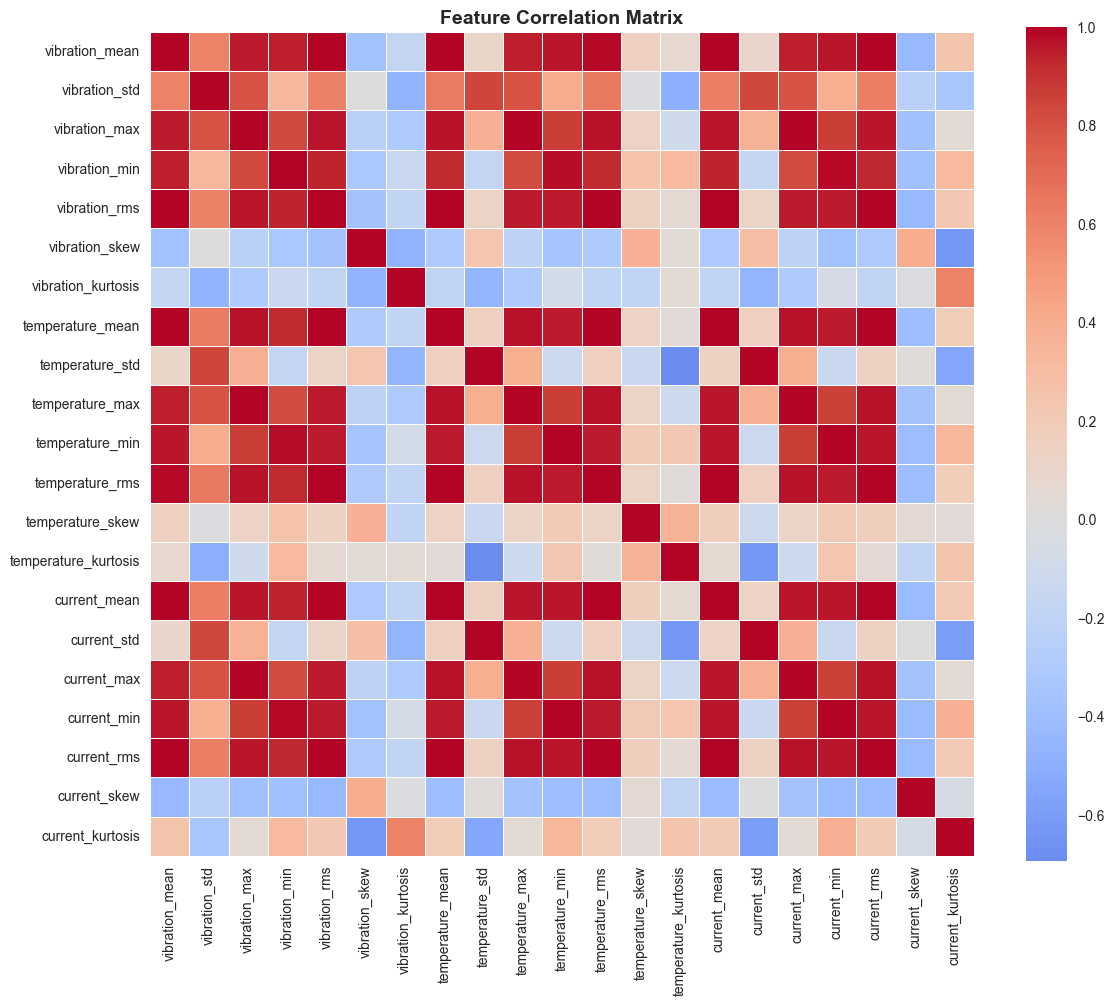

In [7]:
# Select feature columns
feature_cols = [col for col in features_df.columns if col not in ['window_start', 'window_end', 'label']]

# Compute correlation matrix
corr_matrix = features_df[feature_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Importance Analysis

Use statistical tests to identify features that best distinguish normal from anomalous behavior.

In [8]:
from scipy import stats

# Calculate t-test statistics for each feature
normal_features = features_df[features_df['label'] == 0][feature_cols]
anomaly_features = features_df[features_df['label'] == 1][feature_cols]

feature_importance = []
for col in feature_cols:
    t_stat, p_value = stats.ttest_ind(normal_features[col], anomaly_features[col], equal_var=False)
    effect_size = abs(normal_features[col].mean() - anomaly_features[col].mean()) / \
                  (np.sqrt((normal_features[col].var() + anomaly_features[col].var()) / 2))
    
    feature_importance.append({
        'feature': col,
        't_statistic': t_stat,
        'p_value': p_value,
        'effect_size': effect_size,
        'significant': p_value < 0.05
    })

# Sort by effect size
feature_importance_df = pd.DataFrame(feature_importance).sort_values('effect_size', ascending=False)

print("Top 10 most discriminative features:")
feature_importance_df.head(10)

Top 10 most discriminative features:


,feature,t_statistic,p_value,effect_size,significant
16,current_max,-255.347678,1.363135e-25,96.620785,True
9,temperature_max,-218.800174,1.481192e-30,91.111318,True
2,vibration_max,-24.018565,6.591209e-06,14.481955,True
11,temperature_rms,-9.896368,5.508876e-04,6.225345,True
7,temperature_mean,-9.647268,6.102912e-04,6.070130,True
18,current_rms,-8.975600,8.436125e-04,5.670765,True
14,current_mean,-8.630718,9.814772e-04,5.453269,True
4,vibration_rms,-7.670262,1.409572e-03,4.800071,True
0,vibration_mean,-7.177137,1.837947e-03,4.496050,True
10,temperature_min,-4.036591,1.561512e-02,2.551753,True


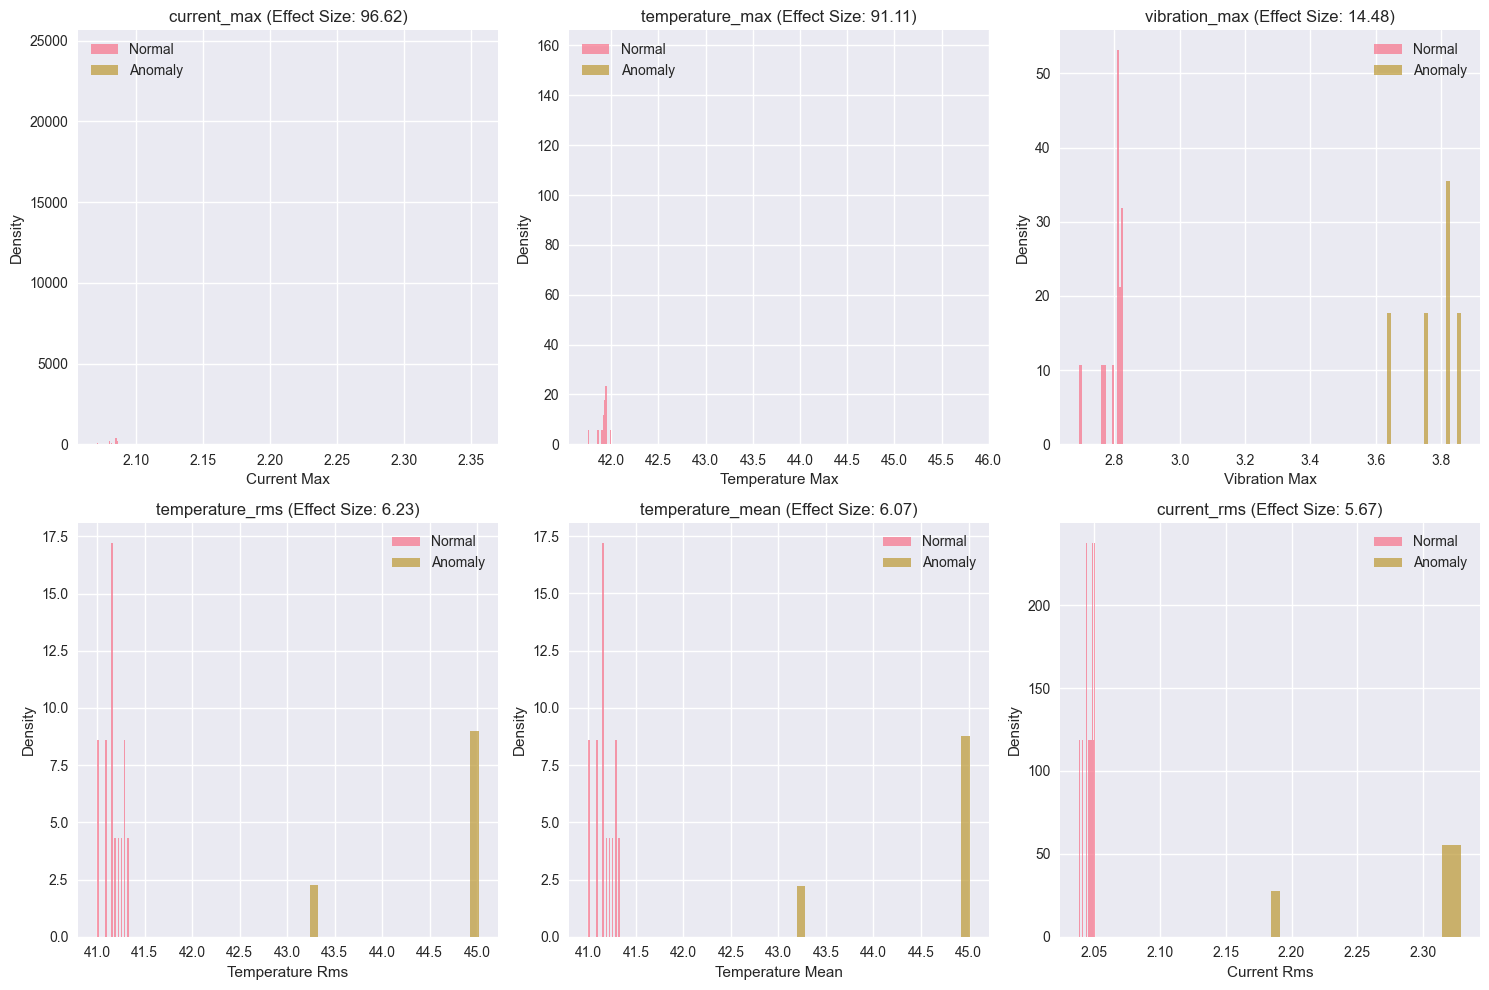

In [9]:
# Visualize feature distributions for top features
top_features = feature_importance_df.head(6)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(top_features):
    axes[i].hist(normal_features[feature], alpha=0.7, label='Normal', bins=20, density=True)
    axes[i].hist(anomaly_features[feature], alpha=0.7, label='Anomaly', bins=20, density=True)
    axes[i].set_xlabel(feature.replace('_', ' ').title())
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].set_title(f'{feature} (Effect Size: {feature_importance_df[feature_importance_df.feature == feature]["effect_size"].values[0]:.2f})')

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated:
1. Generation of realistic synthetic sensor data with normal and anomalous periods
2. Visualization of time series data and statistical distributions
3. Feature extraction using sliding windows
4. Correlation analysis and feature importance ranking

The data shows clear differences between normal and anomalous operating conditions, making it suitable for training anomaly detection models.